# Basetable v2 — With Intraday Features

Extends `basetable.csv` with intraday (within-day) sentiment and volume features
computed from Bluesky and Reddit timestamps.

## Critical data leakage note

The Polymarket price at row `t` is scraped at ~00:03 UTC on day `t`, which
represents the end-of-day price for day `t-1`.  Our prediction target is
`price_change[t] = price[t] - price[t-1]`.

The intraday features in `intraday_features.csv` are indexed by calendar day `t`
(all posts from 00:00 to 23:59 UTC on day `t`).  To predict `price_change[t+1]`
we must use intraday features from day `t` — i.e. a **1-day shift**.

This shift is applied explicitly below so it is visible and auditable.

```
Day t:   posts happen throughout the day (bsky_trump_sent_accel etc.)
         intraday_features row = day t
         shift(1) applied below → these features appear at row t+1 in basetable_v2
Day t+1: price scraped at 00:03 → price_change[t+1] computed
         model uses intraday_features[t] (shifted) to predict price_change[t+1]
```

## Files
- Input : `Data/3_Gold/basetable.csv`  (original, untouched)
- Input : `Data/3_Gold/intraday_features.csv`  (computed in intraday_features.ipynb)
- Output: `Data/3_Gold/basetable_v2.csv`  (merged, shift applied)


## Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Descriptive.house_style import (apply_style, styled_fig, style_ax,
    BG_DARK, BG_PANEL, TEXT_PRIMARY, TEXT_MUTED, GRID_COLOR,
    REPUBLICAN, DEMOCRAT, NEUTRAL)
apply_style()
print("Setup OK")

Setup OK


## Load inputs

In [2]:
# ── Original basetable ────────────────────────────────────────────────────────
basetable = pd.read_csv('../Data/3_Gold/basetable.csv', parse_dates=['date'])
basetable = basetable.sort_values('date').reset_index(drop=True)
print(f"basetable.csv      : {basetable.shape}  "
      f"({basetable['date'].min().date()} -> {basetable['date'].max().date()})")

# ── Intraday features ─────────────────────────────────────────────────────────
intraday_raw = pd.read_csv('../Data/3_Gold/intraday_features.csv', parse_dates=['date'])
intraday_raw = intraday_raw.sort_values('date').reset_index(drop=True)
print(f"intraday_features  : {intraday_raw.shape}")
print(f"Intraday columns   : {[c for c in intraday_raw.columns if c != 'date']}")

basetable.csv      : (124, 97)  (2024-07-05 -> 2024-11-05)
intraday_features  : (124, 17)
Intraday columns   : ['bsky_trump_morning_sent', 'bsky_trump_evening_sent', 'bsky_trump_sent_accel', 'bsky_harris_morning_sent', 'bsky_harris_evening_sent', 'bsky_harris_sent_accel', 'bsky_relative_sent_accel', 'bsky_volume_burst', 'reddit_trump_morning_sent', 'reddit_trump_evening_sent', 'reddit_trump_sent_accel', 'reddit_harris_morning_sent', 'reddit_harris_evening_sent', 'reddit_harris_sent_accel', 'reddit_relative_sent_accel', 'reddit_volume_burst']


## Apply shift(1) — the critical leakage prevention step

In [3]:
# ── Shift intraday features by 1 day ─────────────────────────────────────────
#
# Why shift(1)?
#   intraday_features.csv row for day t = what happened on day t (morning to midnight).
#   We want to predict price_change on day t+1.
#   So intraday features from day t must appear as features for day t+1.
#   shift(1) does exactly this: it moves each value one row forward (one day later).
#
# Example (without shift — WRONG, causes leakage):
#   row 2024-07-10: price_change = +0.02, bsky_trump_sent_accel = +0.15
#   The model would "see" July 10 sentiment when predicting July 10 price change.
#   But July 10 sentiment is formed DURING July 10 — the market already moved!
#
# Example (with shift(1) — CORRECT):
#   row 2024-07-10: price_change = +0.02, bsky_trump_sent_accel = [July 9 value]
#   The model predicts July 10 change using July 9 intraday pattern. Valid.

intraday_cols = [c for c in intraday_raw.columns if c != 'date']

# Rename columns to make the lag explicit
intraday_shifted = intraday_raw.copy()
rename_map = {c: f'{c}_lag1' for c in intraday_cols}
intraday_shifted = intraday_shifted.rename(columns=rename_map)

# Apply the actual shift
intraday_shifted[list(rename_map.values())] = (
    intraday_shifted[list(rename_map.values())].shift(1))

print("Intraday features shifted by 1 day (lag1 suffix added).")
print(f"New column names: {list(rename_map.values())}")
print()
print("Verification — first few rows of shift:")
check_cols = ['date', 'bsky_trump_sent_accel_lag1']
print(intraday_shifted[check_cols].head(5).to_string())
print("(Row 0 is NaN — expected, no day before the first day)")

Intraday features shifted by 1 day (lag1 suffix added).
New column names: ['bsky_trump_morning_sent_lag1', 'bsky_trump_evening_sent_lag1', 'bsky_trump_sent_accel_lag1', 'bsky_harris_morning_sent_lag1', 'bsky_harris_evening_sent_lag1', 'bsky_harris_sent_accel_lag1', 'bsky_relative_sent_accel_lag1', 'bsky_volume_burst_lag1', 'reddit_trump_morning_sent_lag1', 'reddit_trump_evening_sent_lag1', 'reddit_trump_sent_accel_lag1', 'reddit_harris_morning_sent_lag1', 'reddit_harris_evening_sent_lag1', 'reddit_harris_sent_accel_lag1', 'reddit_relative_sent_accel_lag1', 'reddit_volume_burst_lag1']

Verification — first few rows of shift:
        date  bsky_trump_sent_accel_lag1
0 2024-07-05                         NaN
1 2024-07-06                   -0.236997
2 2024-07-07                    0.096800
3 2024-07-08                    0.021245
4 2024-07-09                    0.258810
(Row 0 is NaN — expected, no day before the first day)


## Merge with basetable

In [4]:
# Merge the shifted intraday features into the basetable.
# Use a left join so all basetable rows are kept even if intraday is missing.
df_v2 = basetable.merge(intraday_shifted, on='date', how='left')

print(f"basetable_v2 shape : {df_v2.shape}")
print(f"New intraday cols  : {len(rename_map)}")
print()
print("NaN fraction for new intraday columns:")
intra_lag_cols = list(rename_map.values())
nan_frac = df_v2[intra_lag_cols].isnull().mean().sort_values(ascending=False)
print(nan_frac.round(3).to_string())

basetable_v2 shape : (124, 113)
New intraday cols  : 16

NaN fraction for new intraday columns:
bsky_relative_sent_accel_lag1      0.105
bsky_harris_morning_sent_lag1      0.097
bsky_harris_sent_accel_lag1        0.097
bsky_trump_morning_sent_lag1       0.016
bsky_trump_sent_accel_lag1         0.016
reddit_trump_sent_accel_lag1       0.016
reddit_trump_evening_sent_lag1     0.016
reddit_trump_morning_sent_lag1     0.016
reddit_harris_evening_sent_lag1    0.016
reddit_harris_sent_accel_lag1      0.016
reddit_relative_sent_accel_lag1    0.016
reddit_harris_morning_sent_lag1    0.016
reddit_volume_burst_lag1           0.016
bsky_volume_burst_lag1             0.008
bsky_trump_evening_sent_lag1       0.008
bsky_harris_evening_sent_lag1      0.008


## Quick EDA — new features vs price change

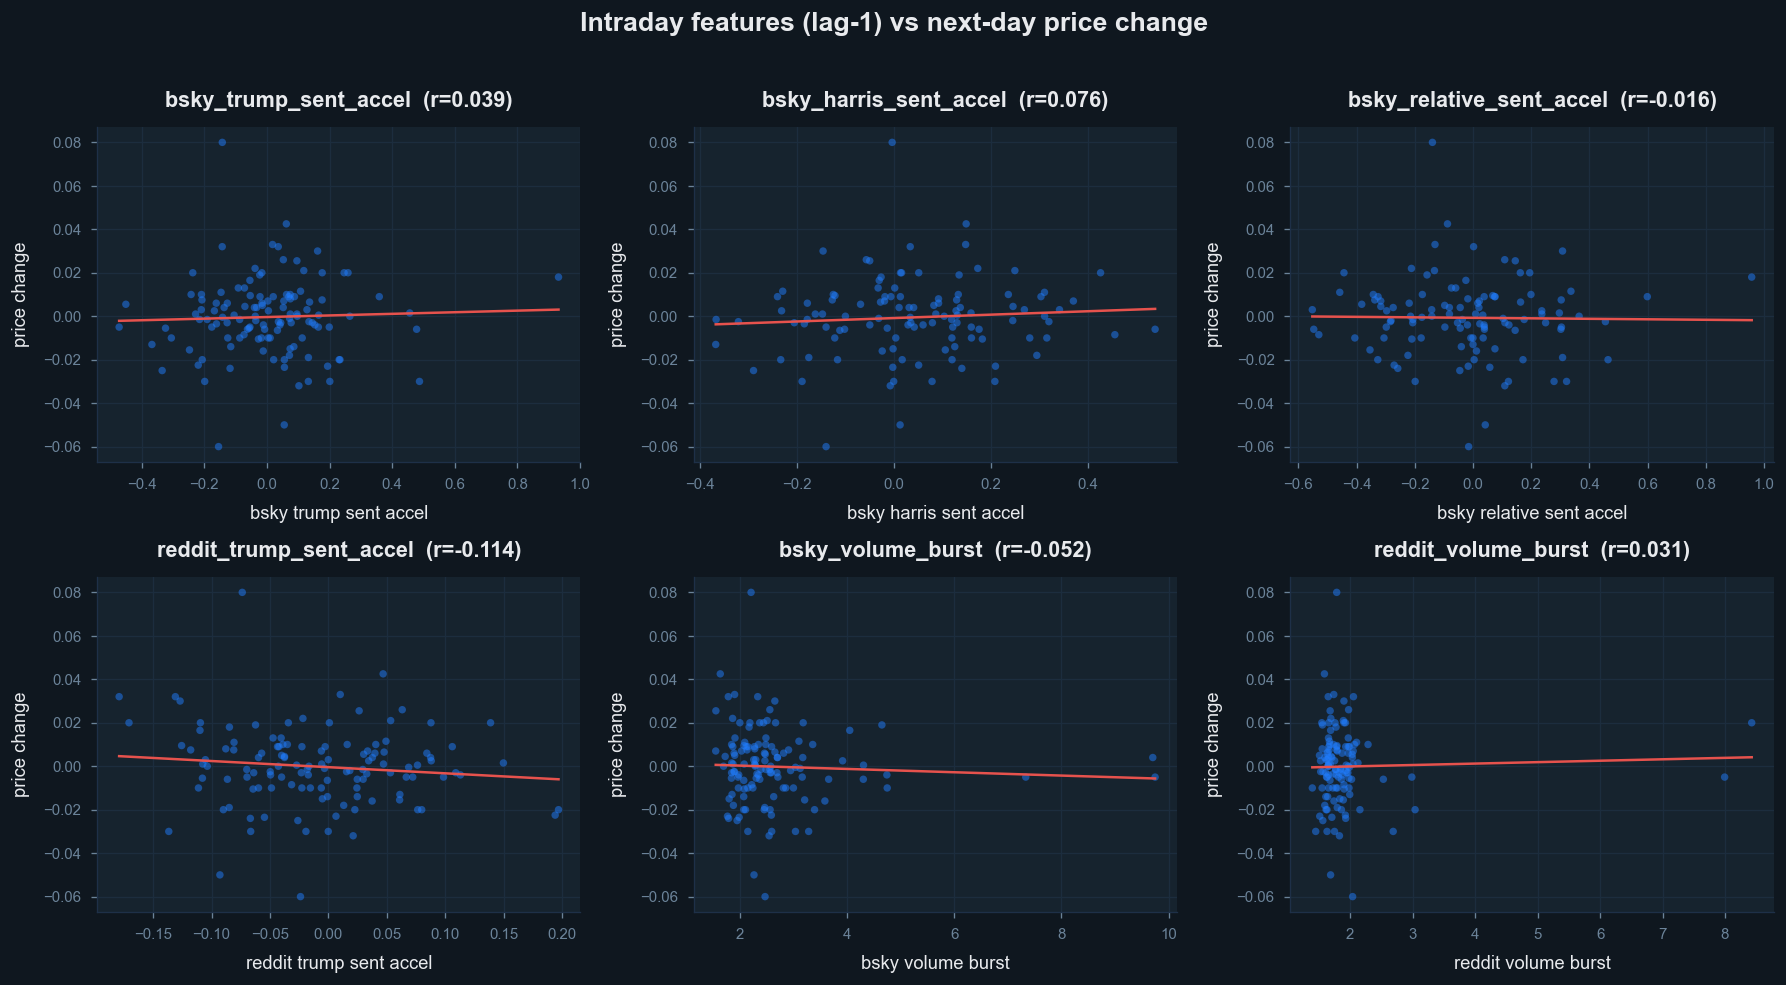

In [5]:
df_v2['price_change'] = df_v2['polymarket_trump_prob'].diff()

# Scatter plots for the most promising intraday features
key_intraday = [
    'bsky_trump_sent_accel_lag1',
    'bsky_harris_sent_accel_lag1',
    'bsky_relative_sent_accel_lag1',
    'reddit_trump_sent_accel_lag1',
    'bsky_volume_burst_lag1',
    'reddit_volume_burst_lag1',
]
key_intraday = [c for c in key_intraday if c in df_v2.columns]

fig, axes = styled_fig(2, 3, figsize=(15, 8),
    title="Intraday features (lag-1) vs next-day price change")

for ax, col in zip(axes.flat, key_intraday):
    sub = df_v2[[col, 'price_change']].dropna()
    ax.scatter(sub[col], sub['price_change'],
               color=DEMOCRAT, alpha=0.5, s=20, edgecolors='none')
    # Add linear trend line
    if len(sub) > 5:
        z = np.polyfit(sub[col], sub['price_change'], 1)
        xline = np.linspace(sub[col].min(), sub[col].max(), 50)
        ax.plot(xline, np.poly1d(z)(xline), color=REPUBLICAN, lw=1.5)
    r = sub[col].corr(sub['price_change'])
    style_ax(ax, xlabel=col.replace('_lag1','').replace('_',' '),
             ylabel='price change',
             title=f'{col.split("_lag1")[0]}  (r={r:.3f})')

plt.tight_layout()
plt.show()

# Remove temp column
df_v2 = df_v2.drop(columns=['price_change'])

## Save basetable_v2.csv

In [6]:
OUT = '../Data/3_Gold/basetable_v2.csv'
df_v2.to_csv(OUT, index=False)
print(f"Saved: {OUT}")
print(f"Shape: {df_v2.shape}  ({len(basetable.columns)} original + {len(rename_map)} intraday lag columns)")
print(f"Date range: {df_v2['date'].min().date()} -> {df_v2['date'].max().date()}")
print()
print("All intraday features are suffixed _lag1 to make the shift explicit.")
print("The original basetable.csv is unchanged.")

Saved: ../Data/3_Gold/basetable_v2.csv
Shape: (124, 113)  (97 original + 16 intraday lag columns)
Date range: 2024-07-05 -> 2024-11-05

All intraday features are suffixed _lag1 to make the shift explicit.
The original basetable.csv is unchanged.
